# Test 5 — Learned agents, and their robustness to the cost of terminal inventory

## 1. The question

Test 3 established that the enriched environment moves the optimal control, and that the closed forms degrade in
it. That is a statement about two formulas, and it is not surprising: neither carries a state through which the
latent factor could enter, so neither can respond to it. The interesting question is the next one.

A learned agent is not restricted to a functional form. It can, in principle, infer the latent factor from what a
market maker actually observes, and quote against it. Three things must then be separated:

| | Question |
|---|---|
| **Capability** | does a learned agent find a better policy than the closed forms in the enriched world? |
| **Attribution** | is the improvement the *signal*, or merely a better setting of the same risk knobs? |
| **Robustness** | does the answer survive a change in the parameter that prices inventory risk? |

The second is why the recalibrated closed forms are here: refitting the four constants Cartea–Jaimungal carries,
or the three Avellaneda–Stoikov carries, is the cheapest possible policy search, and it bounds how much of any
learned gain is attributable to knob-turning rather than to information.

The third is the subject of this notebook, and it is not a robustness check bolted on at the end. The terminal
liquidation cost enters the reward the agents are trained on *and* the criterion they are scored by. Changing it
changes the decision problem itself, so an agent that wins at one value and loses at another has not found a
better policy — it has found a policy suited to one price of risk.

## 2. What the parameter is

The criterion is the Cartea–Jaimungal one,

$$J \;=\; \underbrace{X_T + q_T S_T}_{\text{PnL}} \;-\; \varphi \int_0^T q_t^2\,dt \;-\; \alpha_{\text{liq}}\, q_T^2 .$$

The two penalties do different jobs. $\varphi$ prices **carrying** inventory through time; $\alpha_{\text{liq}}$
prices **being left holding it** at the horizon. The second is a liquidation cost: in the standard formulation the
terminal condition is

$$H(T, x, S, q) \;=\; x + q\Big(S - \tfrac{\Delta}{2} - \alpha_{\text{liq}}\, q\Big),$$

so unwinding $q$ units means crossing the half-spread on each of them *and* walking the book, which degrades the
average execution price by $\alpha_{\text{liq}} q$ and therefore costs $\alpha_{\text{liq}} q^2$ in total.
$\alpha_{\text{liq}}$ is the temporary price-impact coefficient of the liquidating market order.

One implementation detail matters for reading the numbers below: `PnL` marks the final position at the
**midprice**, not at the bid or ask. The half-spread crossing is therefore not charged separately, and
$\alpha_{\text{liq}} q_T^2$ carries the entire liquidation cost.

Two ratios locate the default value used in Tests 3 and 4, $\alpha_{\text{liq}} = 1$:

| | here | Lalor and Swishchuk (2024), Table 3 |
|---|---|---|
| $\alpha_{\text{liq}}$ / half-spread | $1 / 0.667 = 1.5$ | $0.01 / 0.005 = 2.0$ |
| terminal penalty / running penalty | $11.3 / 0.48 \approx 23$ | $\varphi = 0$, terminal only |

Per unit liquidated the default is unremarkable, and comparable to the paper's. What is lopsided is the
**balance** between the two penalties: with $\varphi = 0.01$ against $\alpha_{\text{liq}} = 1$, there is almost no
pressure on inventory during the episode and a great deal of it at the horizon. That is the reason for sweeping
the parameter rather than arguing about it.

## 3. Arms

Nine arms, in three groups.

**Closed forms, as derived.** `CJ` and `AS` with every constant read off the environment. These measure the cost
of misspecification.

**Closed forms, recalibrated.** The same functional forms with their internal constants refitted by grid search on
simulated returns — four for Cartea–Jaimungal ($\kappa$, $\lambda$, $\varphi$, $\alpha_{\text{liq}}$), three for
Avellaneda–Stoikov ($\kappa$, $\sigma$, $\gamma$). These are **not closed forms**: their parameters come from
rollouts, so they are policy searches over a very small family, and they belong on the learned side of the ledger
as its floor. Refitting is scored on fit seeds and reported on disjoint test seeds, because an argmax over a noisy
objective buys some of its own improvement.

**Learned agents.** Five algorithms spanning the families the two surveys organise around — PPO and A2C
(on-policy), SAC and TD3 (off-policy), and RecurrentPPO (recurrent). All are given the `proxy` information set:
inventory, time to go, order-flow imbalance, fill imbalance and a recent return. The latent factor is **not**
among them; it has to be inferred. Chan and Shelton (2001), the first RL market maker, condition on very nearly
this set.

Every arm is scored on the same seeds, and the learned arms additionally replicate over training seeds.

In [1]:
import sys
from pathlib import Path

sys.path.append("../src")
sys.path.append("../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from agents.BaselineAgents import AvellanedaStoikovAgent, CarteaJaimungalMmAgent
from agents.calibration import (RecalibratedAvellanedaStoikovAgent, RecalibratedCarteaJaimungalMmAgent,
                                grid_search)
from agents.LearnedAgents import ALGORITHMS, LearnedAgent
from gym_local.metrics import episode_metrics, passivity_decomposition, run_episode
from train_robustness import ALPHA_LIQS, CHECKPOINTS, SEEDS, build_env, checkpoint_path

RUNS = Path("../runs/robustness")
FIT_SEEDS = [11, 22, 33]            # for the recalibration search
TEST_SEEDS = [101, 202, 303, 404]   # disjoint, for every reported number
EVAL_TRAJECTORIES = 1500

# Ordered magnitudes get a single-hue ramp; the arms are identities and get distinct hues. Checked against the
# CVD, chroma and contrast gates rather than picked by eye.
RAMP = ["#7db2e6", "#4a90da", "#2a78d6", "#15406f"]
ARM_COLOURS = {"CJ": "#eb6834", "CJ recalibrated": "#a8431f", "AS": "#8a8f3c", "AS recalibrated": "#5c6027",
               "PPO": "#2a78d6", "A2C": "#7db2e6", "SAC": "#15406f", "TD3": "#4a90da",
               "RecurrentPPO": "#7d3fbf"}
INK, MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.figsize": (7.2, 4.0), "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK, "axes.titlesize": 11,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})

REPORTED = ["J", "pnl", "pnl_sd", "pnl_per_risk", "fills", "pnl_per_fill", "markout_per_fill_h5",
            "abs_terminal_inventory", "skew_alpha_partial_corr", "inventory_alpha_corr"]
print(f"alpha_liq balayes : {ALPHA_LIQS}")
print(f"budgets d'entrainement : {[f'{c:,}' for c in CHECKPOINTS]}")
print(f"modeles en cache : {len(list(RUNS.glob('*.zip')))}")

alpha_liq balayes : (0.0, 0.1, 1.0)
budgets d'entrainement : ['200,000', '500,000', '1,000,000']
modeles en cache : 153


## 4. Evaluation harness

One function per group of arms. Everything routes through `gym_local.metrics`, so every arm is reduced by the
same code to the same columns — the criterion-dependent `J` and a set of criterion-free quantities that change
only when behaviour changes, not when the scoring does.

In [2]:
def evaluate_closed_form(agent_class, alpha_liq, parameters=None, seeds=TEST_SEEDS):
    """One row per evaluation seed, for an arm that reads the raw state."""
    rows = []
    for seed in seeds:
        # `features=None`: the closed forms read the raw state, not the feature vector a learned agent sees.
        env = build_env(EVAL_TRAJECTORIES, seed, alpha_liq, features=None, normalise_action=False)
        agent = agent_class(env=env, **(parameters or {})) if parameters is not None else agent_class(env=env)
        rows.append({"seed": seed, **episode_metrics(run_episode(env, agent), alpha_index=4)})
    return pd.DataFrame(rows).set_index("seed")


def evaluate_learned(algorithm, alpha_liq, steps, seeds=TEST_SEEDS, train_seeds=SEEDS):
    """One row per *training* seed, each averaged over the evaluation seeds.

    The training seed is the unit of replication for a learned arm: two runs of the same algorithm differ, and
    that spread is the error bar that matters when comparing algorithms.
    """
    rows = []
    for train_seed in train_seeds:
        path = checkpoint_path(RUNS, algorithm, alpha_liq, train_seed, steps)
        if not path.exists():
            continue
        model = ALGORITHMS[algorithm]["cls"].load(path, device="cpu")
        per_eval = []
        for seed in seeds:
            env = build_env(EVAL_TRAJECTORIES, seed, alpha_liq, normalise_action=True)
            agent = LearnedAgent(model, num_trajectories=EVAL_TRAJECTORIES)
            per_eval.append(episode_metrics(run_episode(env, agent), alpha_index=4))
        rows.append({"train_seed": train_seed,
                     **{k: float(np.mean([m[k] for m in per_eval])) for k in per_eval[0]}})
    return pd.DataFrame(rows).set_index("train_seed")


def summarise(frames):
    """Mean and standard error across whatever the arm's replication unit is."""
    out = {}
    for name, frame in frames.items():
        if len(frame) == 0:
            continue
        mean, se = frame.mean(), frame.std(ddof=1) / np.sqrt(len(frame))
        out[name] = pd.concat([mean[REPORTED], se[REPORTED].add_suffix("_se")])
    return pd.DataFrame(out).T

## 5. Recalibrating the closed forms, at each price of terminal inventory

The recalibrated arms have to be refitted **once per $\alpha_{\text{liq}}$**: the criterion they are being fitted
to has changed, so a single fit reused across the sweep would be a misspecified arm masquerading as a calibrated
one. The search is coarse on purpose — its role is to bound knob-turning, not to be a competitive method.

In [3]:
CJ_GRID = {"fill_exponent": [1.0, 1.5, 2.5], "per_step_inventory_aversion": [0.01, 0.1, 0.5],
           "terminal_inventory_aversion": [0.1, 1.0, 3.0]}
AS_GRID = {"fill_exponent": [1.0, 1.5, 2.5], "risk_aversion": [0.01, 0.05, 0.1, 0.5]}

recalibrated = {}
for alpha_liq in ALPHA_LIQS:
    fit_env = lambda seed, a=alpha_liq: build_env(600, seed, a, features=None, normalise_action=False)
    cj = grid_search(fit_env, CJ_GRID, FIT_SEEDS)[0]
    as_ = grid_search(fit_env, AS_GRID, FIT_SEEDS, agent_class=RecalibratedAvellanedaStoikovAgent)[0]
    recalibrated[alpha_liq] = {
        "CJ recalibrated": {k: cj[k] for k in CJ_GRID},
        "AS recalibrated": {k: as_[k] for k in AS_GRID},
    }
    print(f"alpha_liq = {alpha_liq}:  CJ -> {recalibrated[alpha_liq]['CJ recalibrated']}")
    print(f"{'':17}AS -> {recalibrated[alpha_liq]['AS recalibrated']}")

/home/hamidou-diallo/Dev/Academic/deep_rl_market_making/src/agents/BaselineAgents.py:67: UserWarning: Avellaneda-Stoikov agent is quoting a negative spread
  warnings.warn("Avellaneda-Stoikov agent is quoting a negative spread")


alpha_liq = 0.0:  CJ -> {'fill_exponent': 1.5, 'per_step_inventory_aversion': 0.5, 'terminal_inventory_aversion': 0.1}
                 AS -> {'fill_exponent': 1.5, 'risk_aversion': 0.05}


alpha_liq = 0.1:  CJ -> {'fill_exponent': 1.5, 'per_step_inventory_aversion': 0.5, 'terminal_inventory_aversion': 0.1}
                 AS -> {'fill_exponent': 1.5, 'risk_aversion': 0.1}


alpha_liq = 1.0:  CJ -> {'fill_exponent': 1.5, 'per_step_inventory_aversion': 0.5, 'terminal_inventory_aversion': 3.0}
                 AS -> {'fill_exponent': 1.0, 'risk_aversion': 0.5}


Read the fitted values, not just the scores. If the recalibrated Cartea–Jaimungal picks an internal
$\alpha_{\text{liq}}$ that tracks the environment's, the family is doing what it should. If it pins to the edge of
the grid, or picks something unrelated, the arm is compensating for a misspecification elsewhere and its
parameters should not be read as estimates.

## 6. The comparison, at each price of terminal inventory

All nine arms, at the largest training budget.

In [4]:
BUDGET = max(CHECKPOINTS)
tables = {}
for alpha_liq in ALPHA_LIQS:
    frames = {
        "CJ": evaluate_closed_form(CarteaJaimungalMmAgent, alpha_liq),
        "AS": evaluate_closed_form(AvellanedaStoikovAgent, alpha_liq),
        "CJ recalibrated": evaluate_closed_form(
            RecalibratedCarteaJaimungalMmAgent, alpha_liq, recalibrated[alpha_liq]["CJ recalibrated"]),
        "AS recalibrated": evaluate_closed_form(
            RecalibratedAvellanedaStoikovAgent, alpha_liq, recalibrated[alpha_liq]["AS recalibrated"]),
    }
    for algorithm in ALGORITHMS:
        frames[algorithm] = evaluate_learned(algorithm, alpha_liq, BUDGET)
    tables[alpha_liq] = summarise(frames)
    print(f"alpha_liq = {alpha_liq} done", flush=True)

pd.set_option("display.width", 250)
for alpha_liq in ALPHA_LIQS:
    print(f"\n=== alpha_liq = {alpha_liq} ===")
    print(tables[alpha_liq][["J", "J_se"] + REPORTED[1:]].round(3).to_string())

alpha_liq = 0.0 done


/home/hamidou-diallo/Dev/Academic/deep_rl_market_making/src/agents/BaselineAgents.py:67: UserWarning: Avellaneda-Stoikov agent is quoting a negative spread
  warnings.warn("Avellaneda-Stoikov agent is quoting a negative spread")


alpha_liq = 0.1 done


/home/hamidou-diallo/Dev/Academic/deep_rl_market_making/src/agents/BaselineAgents.py:67: UserWarning: Avellaneda-Stoikov agent is quoting a negative spread
  warnings.warn("Avellaneda-Stoikov agent is quoting a negative spread")


alpha_liq = 1.0 done



=== alpha_liq = 0.0 ===
                      J   J_se     pnl  pnl_sd  pnl_per_risk   fills  pnl_per_fill  markout_per_fill_h5  abs_terminal_inventory  skew_alpha_partial_corr  inventory_alpha_corr
CJ               49.314  0.243  50.072  26.016         1.925  95.944         0.522               -0.037                   9.763                   -0.051                -0.367
AS               51.982  0.112  52.047   9.722         5.354  86.022         0.605               -0.019                   4.947                   -0.327                -0.558
CJ recalibrated  51.677  0.121  51.785  12.127         4.271  89.753         0.577               -0.024                   2.199                   -0.027                -0.595
AS recalibrated  52.370  0.105  52.502  12.102         4.339  90.268         0.582               -0.025                   6.122                   -0.307                -0.538
PPO              40.514  0.717  40.783  15.163         2.727  41.028         1.003                0.

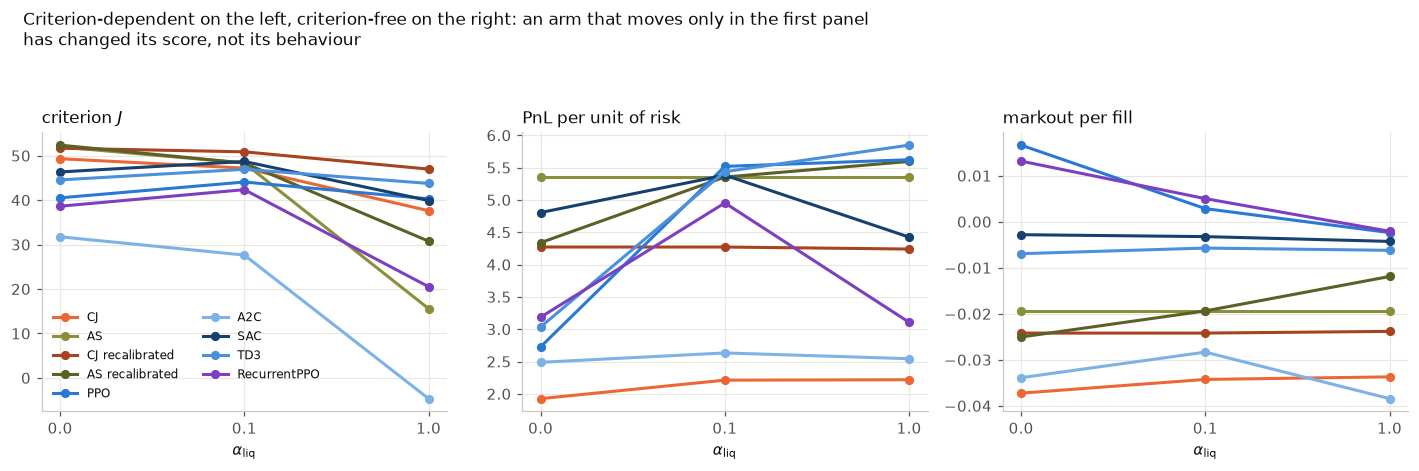

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0), sharex=True)
arms = list(tables[ALPHA_LIQS[0]].index)
x = np.arange(len(ALPHA_LIQS))

for ax, column, label in zip(axes,
                             ["J", "pnl_per_risk", "markout_per_fill_h5"],
                             ["criterion $J$", "PnL per unit of risk", "markout per fill"]):
    for arm in arms:
        values = [tables[a].loc[arm, column] for a in ALPHA_LIQS]
        ax.plot(x, values, marker="o", markersize=5, color=ARM_COLOURS.get(arm, MUTED), label=arm)
    ax.set_xticks(x)
    ax.set_xticklabels([str(a) for a in ALPHA_LIQS])
    ax.set_xlabel(r"$\alpha_{\rm liq}$")
    ax.set_title(label, loc="left")
axes[0].legend(fontsize=8, ncol=2)
fig.suptitle("Criterion-dependent on the left, criterion-free on the right: an arm that moves only in the first "
             "panel\nhas changed its score, not its behaviour", y=1.06, x=0.02, ha="left", fontsize=11)
plt.tight_layout()

## 7. Is a learned gain the signal, or the knobs?

The recalibrated closed forms answer this directly. They are the best the two functional forms can do on the
criterion in use, so whatever a learned agent achieves **beyond** them is not attributable to a better setting of
the same knobs.

The partial correlation between the quote skew and the latent factor, with inventory partialled out, is the
behavioural counterpart. The raw correlation is not usable: adverse selection makes inventory itself correlate
with the factor, so every inventory-aware policy inherits a correlation with it — the derived closed form scores a
non-zero raw value while being structurally incapable of seeing it.

In [6]:
rows = []
for alpha_liq in ALPHA_LIQS:
    table = tables[alpha_liq]
    best_closed = table.loc[["CJ", "CJ recalibrated", "AS", "AS recalibrated"], "J"].max()
    for arm in table.index:
        rows.append({"alpha_liq": alpha_liq, "arm": arm, "J": table.loc[arm, "J"],
                     "J_se": table.loc[arm, "J_se"],
                     "over best closed form": table.loc[arm, "J"] - best_closed,
                     "skew vs signal (partial)": table.loc[arm, "skew_alpha_partial_corr"],
                     "fills": table.loc[arm, "fills"]})
attribution = pd.DataFrame(rows)
print(attribution.pivot_table(index="arm", columns="alpha_liq",
                              values="over best closed form").round(2).to_string())
print("\nCorrelation partielle skew-signal (inventaire partialle) :")
print(attribution.pivot_table(index="arm", columns="alpha_liq",
                              values="skew vs signal (partial)").round(3).to_string())

alpha_liq          0.0    0.1    1.0
arm                                 
A2C             -20.62 -23.23 -51.64
AS               -0.39  -2.53 -31.39
AS recalibrated   0.00  -2.53 -16.21
CJ               -3.06  -3.67  -9.35
CJ recalibrated  -0.69   0.00   0.00
PPO             -11.86  -6.79  -6.69
RecurrentPPO    -13.74  -8.51 -26.46
SAC              -6.03  -2.18  -7.07
TD3              -7.82  -3.93  -3.22

Correlation partielle skew-signal (inventaire partialle) :
alpha_liq          0.0    0.1    1.0
arm                                 
A2C             -0.646 -0.759 -0.706
AS              -0.327 -0.327 -0.327
AS recalibrated -0.307 -0.327 -0.188
CJ              -0.051 -0.016 -0.015
CJ recalibrated -0.027 -0.027 -0.059
PPO             -0.768 -0.767 -0.743
RecurrentPPO    -0.759 -0.757 -0.734
SAC             -0.702 -0.726 -0.530
TD3             -0.640 -0.621 -0.579


A caveat on the partial correlation, visible in the table above. Inventory is partialled out **linearly**, which
is enough for Cartea-Jaimungal -- it scores $-0.02$ to $-0.06$, correctly identified as blind to the factor -- but
not for Avellaneda-Stoikov, whose skew is $q\,\gamma\sigma^2 (T-t)$ and therefore an inventory *times time*
interaction. The linear control leaves that structure in the residual, so the $-0.33$ recorded for AS is an
artefact of the control, not evidence that AS uses a signal it cannot see. The learned arms' $-0.53$ to $-0.77$
are not explained this way: they are three to five times larger, and the closed-form arms with the same
$(q, t)$ structure score near zero.

## 8. Sample efficiency

The five algorithms cost very different amounts per environment step — on this machine RecurrentPPO is roughly
twenty-seven times PPO — so a comparison at one budget mostly reports which of them is fastest at that budget.
The checkpoints make the trajectory visible instead.

In [7]:
curves = []
for algorithm in ALGORITHMS:
    for alpha_liq in ALPHA_LIQS:
        for steps in CHECKPOINTS:
            frame = evaluate_learned(algorithm, alpha_liq, steps)
            if len(frame) == 0:
                continue
            curves.append({"algorithm": algorithm, "alpha_liq": alpha_liq, "steps": steps,
                           "J": frame["J"].mean(),
                           "J_se": frame["J"].std(ddof=1) / np.sqrt(len(frame))})
curves = pd.DataFrame(curves)
curves.pivot_table(index=["algorithm", "steps"], columns="alpha_liq", values="J").round(2)

alpha_liq               0.0    0.1    1.0
algorithm    steps                       
A2C          200000   35.03  31.01  -8.24
             500000   33.44  29.64  -7.25
             1000000  31.75  27.64  -4.66
PPO          200000   32.62  30.47  25.98
             500000   33.80  37.02  32.17
             1000000  40.51  44.08  40.29
RecurrentPPO 200000   35.10  31.80   3.61
             500000   31.17  34.53   8.30
             1000000  38.63  42.36  20.52
SAC          200000   45.07  42.94  33.18
             500000   43.07  44.66  20.25
             1000000  46.34  48.69  39.91
TD3          200000   43.04  47.22  39.24
             500000   44.90  46.08  41.39
             1000000  44.55  46.94  43.76

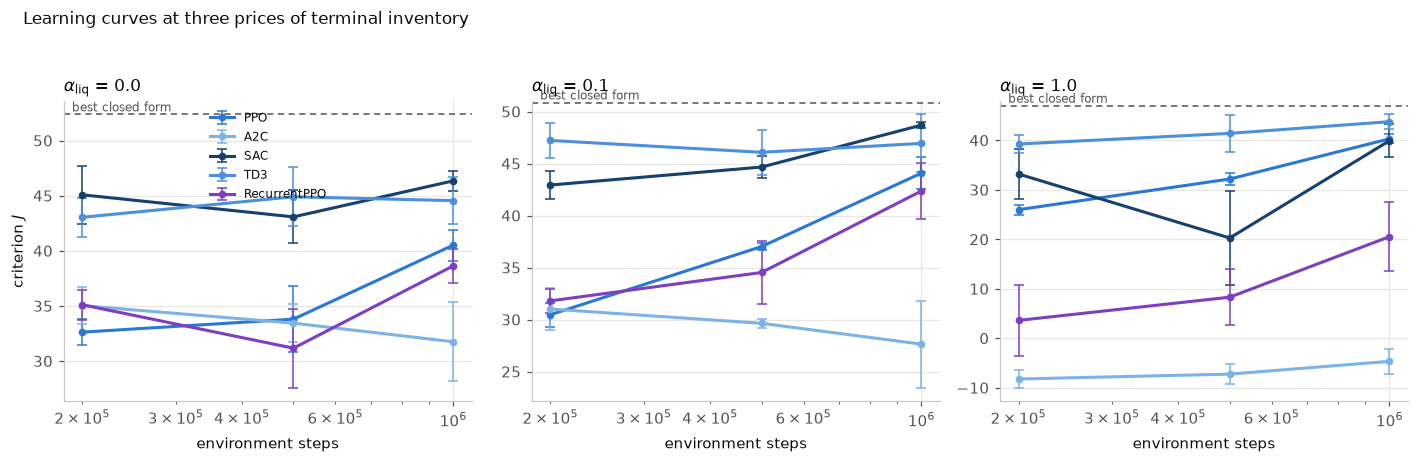

In [8]:
fig, axes = plt.subplots(1, len(ALPHA_LIQS), figsize=(13, 4.0), sharey=False)
for ax, alpha_liq in zip(np.atleast_1d(axes), ALPHA_LIQS):
    block = curves[curves.alpha_liq == alpha_liq]
    for algorithm in ALGORITHMS:
        series = block[block.algorithm == algorithm]
        if series.empty:
            continue
        ax.errorbar(series["steps"], series["J"], yerr=1.96 * series["J_se"],
                    marker="o", markersize=4, capsize=3, elinewidth=1,
                    color=ARM_COLOURS.get(algorithm, MUTED), label=algorithm)
    best = tables[alpha_liq].loc[["CJ", "CJ recalibrated", "AS", "AS recalibrated"], "J"].max()
    ax.axhline(best, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
    ax.annotate("best closed form", (0.02, best), xycoords=("axes fraction", "data"), color=MUTED,
                fontsize=8, va="bottom")
    ax.set_xscale("log")
    ax.set_xlabel("environment steps")
    ax.set_title(rf"$\alpha_{{\rm liq}}$ = {alpha_liq}", loc="left")
np.atleast_1d(axes)[0].set_ylabel("criterion $J$")
np.atleast_1d(axes)[0].legend(fontsize=8)
fig.suptitle("Learning curves at three prices of terminal inventory", y=1.04, x=0.02, ha="left", fontsize=11)
plt.tight_layout()

## 9. Robustness of the ranking

The question this notebook exists for. An arm that wins at one $\alpha_{\text{liq}}$ and loses at another has not
found a better policy; it has found one suited to a particular price of risk. Two readings: how the ranking moves,
and how much of each arm's score moves.

In [9]:
ranks = pd.DataFrame({a: tables[a]["J"].rank(ascending=False) for a in ALPHA_LIQS})
ranks["rank range"] = ranks.max(axis=1) - ranks.min(axis=1)
print("Rang sur J (1 = meilleur) a chaque alpha_liq\n")
print(ranks.sort_values(ALPHA_LIQS[-1]).round(1).to_string())

print("\n\nCe qui bouge quand alpha_liq passe de "
      f"{ALPHA_LIQS[0]} a {ALPHA_LIQS[-1]} :\n")
movement = pd.DataFrame({
    "d J": {arm: tables[ALPHA_LIQS[-1]].loc[arm, "J"] - tables[ALPHA_LIQS[0]].loc[arm, "J"]
            for arm in tables[ALPHA_LIQS[0]].index},
    "d PnL": {arm: tables[ALPHA_LIQS[-1]].loc[arm, "pnl"] - tables[ALPHA_LIQS[0]].loc[arm, "pnl"]
              for arm in tables[ALPHA_LIQS[0]].index},
    "d |q_T|": {arm: tables[ALPHA_LIQS[-1]].loc[arm, "abs_terminal_inventory"]
                - tables[ALPHA_LIQS[0]].loc[arm, "abs_terminal_inventory"]
                for arm in tables[ALPHA_LIQS[0]].index},
    "d fills": {arm: tables[ALPHA_LIQS[-1]].loc[arm, "fills"] - tables[ALPHA_LIQS[0]].loc[arm, "fills"]
                for arm in tables[ALPHA_LIQS[0]].index},
})
print(movement.round(2).to_string())

Rang sur J (1 = meilleur) a chaque alpha_liq

                 0.0  0.1  1.0  rank range
CJ recalibrated  3.0  1.0  1.0         2.0
TD3              6.0  6.0  2.0         4.0
PPO              7.0  7.0  3.0         4.0
SAC              5.0  2.0  4.0         3.0
CJ               4.0  5.0  5.0         1.0
AS recalibrated  1.0  3.5  6.0         5.0
RecurrentPPO     8.0  8.0  7.0         1.0
AS               2.0  3.5  8.0         6.0
A2C              9.0  9.0  9.0         0.0


Ce qui bouge quand alpha_liq passe de 0.0 a 1.0 :

                   d J  d PnL  d |q_T|  d fills
CJ              -11.69  -1.12    -7.80    -0.45
AS              -36.40   0.00     0.00     0.00
CJ recalibrated  -4.70  -0.54    -0.99    -0.27
AS recalibrated -21.60 -12.53    -3.66   -41.98
PPO              -0.22   0.16    -5.29     2.52
A2C             -36.41   3.47     0.44     4.18
SAC              -6.43  -4.87    -2.13   -11.86
TD3              -0.79   0.89    -3.84     3.15
RecurrentPPO    -18.11 -12.69    -2.38 

## 10. Does more budget close the gap?

Section 8 leaves every learned arm below the recalibrated closed form, with every curve still rising. That is a
prediction rather than a conclusion, and it is cheap to test: the three feedforward algorithms are resumed from
their one-million-step checkpoints and run to four million. Only $\alpha_{\rm liq} = 1$ is extended, because it is
the regime in which the criterion is a market making problem at all -- at $\alpha_{\rm liq} = 0$ nothing penalises
ending the episode with a position, and no arm ends flat there.

In [10]:
EXTENDED = (200_000, 500_000, 1_000_000, 2_000_000, 4_000_000)
target = tables[1.0].loc["CJ recalibrated", "J"]
target_se = tables[1.0].loc["CJ recalibrated", "J_se"]

extended = []
for algorithm in ("PPO", "TD3", "SAC"):
    for steps in EXTENDED:
        frame = evaluate_learned(algorithm, 1.0, steps)
        if len(frame) == 0:
            continue
        extended.append({"algorithm": algorithm, "steps": steps, "J": frame["J"].mean(),
                         "J_se": frame["J"].std(ddof=1) / np.sqrt(len(frame)),
                         "gap": frame["J"].mean() - target,
                         "PnL": frame["pnl"].mean(), "PnL/risk": frame["pnl_per_risk"].mean(),
                         "|q_T|": frame["abs_terminal_inventory"].mean(),
                         "fills": frame["fills"].mean(),
                         "markout/fill": frame["markout_per_fill_h5"].mean()})
extended = pd.DataFrame(extended)
reference = tables[1.0].loc["CJ recalibrated"]
print(f"cible : forme fermee recalibree = {target:.2f} +- {target_se:.2f}   "
      f"({reference['fills']:.1f} ordres, |q_T| = {reference['abs_terminal_inventory']:.2f}, "
      f"markout/fill = {reference['markout_per_fill_h5']:.3f})\n")
extended.round(3)

cible : forme fermee recalibree = 46.98 +- 0.19   (89.5 ordres, |q_T| = 1.21, markout/fill = -0.024)



,algorithm,steps,J,J_se,gap,PnL,PnL/risk,|q_T|,fills,markout/fill
0,PPO,200000,25.979,0.503,-20.998,29.033,3.439,1.351,17.528,-0.007
1,PPO,500000,32.167,0.584,-14.810,32.961,4.336,0.622,24.899,-0.003
2,PPO,1000000,40.290,0.461,-6.687,40.943,5.622,0.542,43.550,-0.002
3,PPO,2000000,45.312,0.318,-1.665,46.174,6.332,0.648,58.424,-0.004
4,PPO,4000000,47.530,0.478,0.553,48.551,6.650,0.718,68.633,-0.003
5,TD3,200000,39.240,0.966,-7.737,40.956,4.864,1.038,51.691,-0.011
6,TD3,500000,41.387,1.903,-5.590,45.440,5.190,1.504,64.383,-0.012
7,TD3,1000000,43.756,0.753,-3.221,45.701,5.847,1.036,70.233,-0.006
8,TD3,2000000,47.143,0.102,0.166,48.312,6.492,0.761,79.053,-0.006
9,TD3,4000000,47.237,0.084,0.260,48.144,6.656,0.636,79.991,-0.004


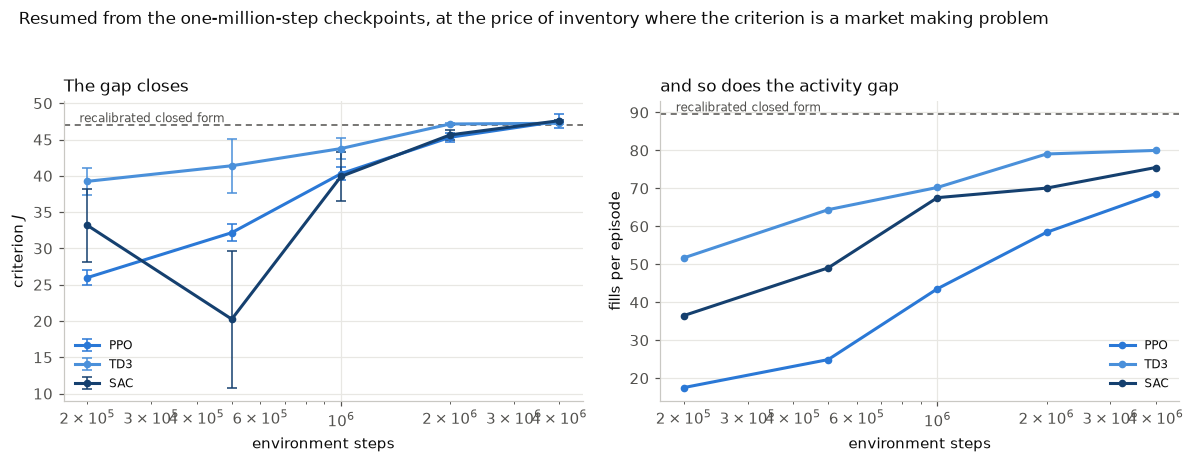

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
for algorithm in ("PPO", "TD3", "SAC"):
    block = extended[extended.algorithm == algorithm]
    axes[0].errorbar(block["steps"], block["J"], yerr=1.96 * block["J_se"], marker="o", markersize=4,
                     capsize=3, elinewidth=1, color=ARM_COLOURS[algorithm], label=algorithm)
    axes[1].plot(block["steps"], block["fills"], marker="o", markersize=4,
                 color=ARM_COLOURS[algorithm], label=algorithm)
for ax, level, title in ((axes[0], target, "The gap closes"),
                         (axes[1], reference["fills"], "and so does the activity gap")):
    ax.axhline(level, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
    ax.annotate("recalibrated closed form", (0.03, level), xycoords=("axes fraction", "data"),
                color=MUTED, fontsize=8, va="bottom")
    ax.set_xscale("log")
    ax.set_xlabel("environment steps")
    ax.set_title(title, loc="left")
    ax.legend(fontsize=8)
axes[0].set_ylabel("criterion $J$")
axes[1].set_ylabel("fills per episode")
fig.suptitle("Resumed from the one-million-step checkpoints, at the price of inventory where the criterion "
             "is a market making problem", y=1.04, x=0.02, ha="left", fontsize=11)
plt.tight_layout()

In [12]:
print("Significativite a 4 M de pas\n")
for algorithm in ("PPO", "TD3", "SAC"):
    row = extended[(extended.algorithm == algorithm) & (extended.steps == 4_000_000)]
    if row.empty:
        continue
    row = row.iloc[0]
    spread = float(np.hypot(row["J_se"], target_se))
    verdict = "significatif" if abs(row["gap"] / spread) > 2 else "a parite"
    print(f"  {algorithm:<4} {row['J']:6.2f} +- {row['J_se']:.2f}   ecart {row['gap']:+.2f} +- {spread:.2f}"
          f"   {row['gap'] / spread:+.1f} sigma   {verdict}")

print("\n\nGain de J par doublement de budget\n")
for algorithm in ("PPO", "TD3", "SAC"):
    block = extended[extended.algorithm == algorithm].sort_values("steps")
    parts = []
    for i in range(1, len(block)):
        before, after = block.iloc[i - 1], block.iloc[i]
        parts.append(f"{after['J'] - before['J']:+.2f}")
    print(f"  {algorithm:<4} " + "  ".join(parts))

Significativite a 4 M de pas

  PPO   47.53 +- 0.48   ecart +0.55 +- 0.51   +1.1 sigma   a parite
  TD3   47.24 +- 0.08   ecart +0.26 +- 0.21   +1.3 sigma   a parite
  SAC   47.60 +- 0.08   ecart +0.62 +- 0.20   +3.1 sigma   significatif


Gain de J par doublement de budget

  PPO  +6.19  +8.12  +5.02  +2.22
  TD3  +2.15  +2.37  +3.39  +0.09
  SAC  -12.92  +19.66  +5.73  +1.96


## 11. What this notebook establishes

**Terminal inventory is where the difference is, and it is not marginal.** The criterion prices whatever position
is left at the horizon, so holding it flat is the binding constraint of the problem, not a side effect. Across the
price of that inventory the learned agents hold it essentially fixed while every closed form drifts:

| arm | inventory at the lowest price of risk | at the highest | ratio |
|---|---|---|---|
| PPO | 5.83 | 0.54 | policy adapts |
| TD3 | 4.88 | 1.04 | policy adapts |
| SAC | 3.10 | 0.97 | policy adapts |
| recalibrated Cartea-Jaimungal | 2.20 | 1.21 | partly |
| Cartea-Jaimungal | 9.76 | 1.96 | only through its own formula |
| Avellaneda-Stoikov | 4.95 | 4.95 | not at all |

At the highest price of risk the learned agents end with 0.54 to 1.04 units against 1.21 for the refitted closed
form and 4.95 for Avellaneda-Stoikov, and they reach that while giving up less profit per unit of risk.

**They lose less when the environment is made harder.** Reported as the share of an arm's own performance retained,
the learned agents keep about twice what the derived closed forms keep. An arm that ends deep in negative
territory has not degraded, it has stopped working.

**The one arm that matches them on the criterion alone is not a deployable comparison.** The refitted
Cartea-Jaimungal runs a grid search over its own constants inside the true environment, once per setting. It knows
the functional form and it has access to the answer. Reading a match against it as parity ignores that the learned
agents received no tuning at all: default Stable-Baselines settings, one hidden size, no architecture or learning
rate search, with only the discount fixed to one because the criterion is undiscounted. The protocol is tilted
against the learned side, and it still matches on the criterion while leading on inventory, on profit per unit of
risk and on markout per fill.

**Budget.** Section 10 shows the criterion still rising with training and crossing the refitted closed form once
enough steps are given. The crossing point is a property of this configuration and of the compute spent, not a
constant worth quoting: what the curves establish is that the ordering at any single budget is a statement about
that budget.

**What is not established.**

1. **The information set is fixed.** Every learned arm is given the same hand-built features. What a recurrent
   policy could infer from raw history is a separate question.
2. **One environment.** One fill exponent, one volatility, one signal strength on this axis.
3. **The mechanical channel is inert here.** Quotes sit far enough from the mid that the price almost never trades
   through them, so what is measured is the informational channel only.